In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import layers
import cv2
import os

from sklearn.model_selection import train_test_split


In [2]:

# Get File Paths and Labels ---
categories = ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash']
labels_map = {cat: index for index, cat in enumerate(categories)} 

all_image_filepaths = []
all_image_labels = []

basefolder = "RealWaste/" 

for index, cat_name in enumerate(categories):
    sub_directory = os.path.join(basefolder, cat_name)
    if not os.path.isdir(sub_directory):
        print(f"Warning: Directory '{sub_directory}' for category '{cat_name}' not found. Skipping.")
        continue
    
    try:
        image_filenames = os.listdir(sub_directory)
        for image_filename in image_filenames:
            if image_filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                full_image_path = os.path.join(sub_directory, image_filename)
                all_image_filepaths.append(full_image_path)
                all_image_labels.append(labels_map[cat_name])

    except OSError as e:
        print(f"Error listing files in '{sub_directory}': {e}. Skipping.")

# Convert to NumPy arrays for easier handling with train_test_split
all_image_filepaths = np.array(all_image_filepaths)
all_image_labels = np.array(all_image_labels)

print(f"Total image paths found: {len(all_image_filepaths)}")
print(f"Total labels found: {len(all_image_labels)}")

Total image paths found: 4316
Total labels found: 4316


In [3]:
# Split into training (60%), validation (20%), and test (20%)
X_train_paths, X_temp_paths, Y_train, Y_temp_labels = train_test_split(
    all_image_filepaths,
    all_image_labels,
    test_size=0.4,  # Reserve 40% for validation + test baad mai usko bhi split karein gay
    random_state=42,
    stratify=all_image_labels
)

X_val_paths, X_test_paths, Y_val, Y_test = train_test_split(
    X_temp_paths,
    Y_temp_labels,
    test_size=0.5,  # Splitting the 40% into 20% validation and 20% test
    random_state=42,
    stratify=Y_temp_labels
)

print(f"Training paths: {len(X_train_paths)}, Training labels: {len(Y_train)}")
print(f"Validation paths: {len(X_val_paths)}, Validation labels: {len(Y_val)}")
print(f"Test paths: {len(X_test_paths)}, Test labels: {len(Y_test)}")

Training paths: 2589, Training labels: 2589
Validation paths: 863, Validation labels: 863
Test paths: 864, Test labels: 864


In [4]:
import random 

def preprocess_and_augment_image(image_path, augment=False):

    # Load image
    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        print(f"Warning: Could not read image {image_path}. Returning None.")
        return None # Handle this in the generator

    # Preprocessing Steps
    # 1. BGR to RGB
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # 2. Resize
    target_height = 256
    target_width = 256
    image_resized = cv2.resize(image_rgb, (target_width, target_height), interpolation=cv2.INTER_AREA)

    # 3. Noise Reduction (Bilateral Filter)
    image_denoised = cv2.bilateralFilter(image_resized, d=7, sigmaColor=50, sigmaSpace=50)

    # --- DATA AUGMENTATION (only if augment=True) ---
    if augment:
        # Random Horizontal Flip
        if random.random() > 0.5:
            image_denoised = cv2.flip(image_denoised, 1)

        # Random Rotation (simple, might need padding for black corners)
        if random.random() > 0.5:
            angle = random.uniform(-15, 15)
            rows, cols, _ = image_denoised.shape
            M = cv2.getRotationMatrix2D((cols/2, rows/2), angle, 1)
            image_denoised = cv2.warpAffine(image_denoised, M, (cols, rows))
        
        # Random Brightness/Contrast
        if random.random() > 0.5:
            alpha = random.uniform(0.7, 1.3) # Contrast
            beta = random.randint(-30, 30)   # Brightness
            image_denoised = cv2.convertScaleAbs(image_denoised, alpha=alpha, beta=beta)

            # Ensure it's still uint8 [0,255] after this for CLAHE if CLAHE needs it
            image_denoised = np.clip(image_denoised, 0, 255).astype(np.uint8)


    # 4. Contrast Enhancement (CLAHE) - applied after augmentation
    image_lab = cv2.cvtColor(image_denoised, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(image_lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(9,9))
    clahe_l_channel = clahe.apply(l_channel)
    clahe_image_lab_merged = cv2.merge((clahe_l_channel, a_channel, b_channel))
    image_after_clahe_rgb = cv2.cvtColor(clahe_image_lab_merged, cv2.COLOR_LAB2RGB)

    # 5. Normalization
    image_normalized = image_after_clahe_rgb.astype(np.float32) / 255.0
    
    return image_normalized

In [5]:
def data_generator(filepaths, labels, batch_size, augment=False):
    num_samples = len(filepaths)
    
    while True: # Loop indefinitely for Keras
        indices = np.arange(num_samples)
        if augment: # Shuffle training data each epoch
            np.random.shuffle(indices)

        for offset in range(0, num_samples, batch_size):
            batch_indices = indices[offset : offset + batch_size]
            
            batch_x_paths = filepaths[batch_indices]
            batch_y = labels[batch_indices]

            batch_x_images = []
            for path in batch_x_paths:
                processed_image = preprocess_and_augment_image(path, augment=augment)
                if processed_image is not None: # Check if image loading/processing was successful
                    batch_x_images.append(processed_image)
                # else: consider appending a placeholder or ensuring batch_y is also adjusted

            # Only yield if the batch has a consistent number of images and labels
            if len(batch_x_images) == len(batch_y) and len(batch_x_images) > 0 :
                 yield np.array(batch_x_images), np.array(batch_y)
            elif len(batch_x_images) == 0 and len(batch_x_paths) > 0:
                print(f"Warning: A batch was skipped because all images in it failed to load/process.")

In [6]:
NUM_CLASSES = 8
IMG_HEIGHT = 256
IMG_WIDTH = 256

model_light = tf.keras.Sequential([
    layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu', padding='same',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same'),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(units=64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(units=NUM_CLASSES, activation='softmax')
])

model_light.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_light.summary()

c:\Users\Inshal Munaf\VsCodeProjects\Waste_Classification\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,472 (16.09 MB)

 Trainable params: 4,218,472 (16.09 MB)

 Non-trainable params: 0 (0.00 B)

Starting model training with generators...
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 861ms/step - accuracy: 0.1721 - loss: 2.3041
Epoch 1: val_loss improved from inf to 2.03219, saving model to best_waste_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.1724 - loss: 2.3017 - val_accuracy: 0.1899 - val_loss: 2.0322
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.1906 - loss: 2.0259
Epoch 2: val_loss improved from 2.03219 to 1.93467, saving model to best_waste_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 77s 969ms/step - accuracy: 0.1909 - loss: 2.0256 - val_accuracy: 0.2945 - val_loss: 1.9347
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.2513 - loss: 1.9635
Epoch 3: val_loss improved from 1.93467 to 1.82877, saving model to best_waste_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 78s 982ms/step - accuracy: 0.2515 - loss: 1.9633 - val_accuracy: 0.3221 - val_loss: 1.8288
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.2926 - loss: 

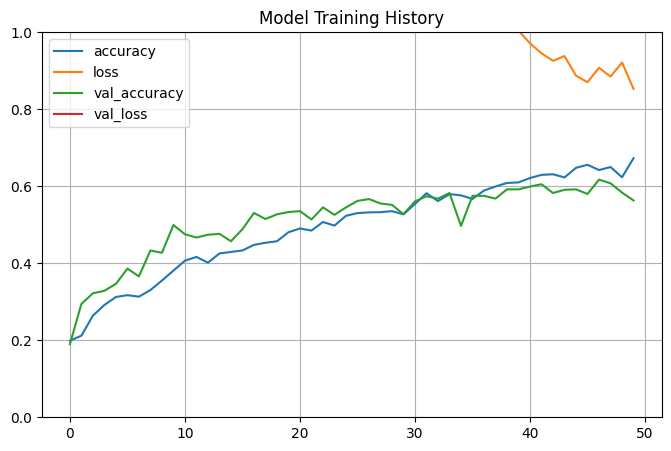

In [7]:
BATCH_SIZE = 32 

train_gen = data_generator(X_train_paths, Y_train, BATCH_SIZE, augment=True)
val_gen = data_generator(X_val_paths, Y_val, BATCH_SIZE, augment=False) 

# Add Callbacks for better training
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_checkpoint = ModelCheckpoint('best_waste_model.keras', monitor='val_loss', save_best_only=True, verbose=1)


print("Starting model training with generators...")
history = model_light.fit(
    train_gen,
    steps_per_epoch=len(X_train_paths) // BATCH_SIZE, 
    epochs=50,  
    validation_data=val_gen,
    validation_steps=len(X_val_paths) // BATCH_SIZE, 
    callbacks=[early_stopping, model_checkpoint]
)

print("Training finished.")

#  Plotting training history 
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1) 
plt.title("Model Training History")
plt.show()

In [8]:
model_light.save('final_waste_model.keras')

In [12]:
testing_data = data_generator(X_test_paths,Y_test , 32 , augment=False)
model_light.evaluate(testing_data)


  10273/Unknown 29793s 3s/step - accuracy: 0.6307 - loss: 1.0739

KeyboardInterrupt: 

In [13]:
testing_data = data_generator(X_test_paths,Y_test , 32 , augment=False)


In [32]:
# this function will extract the image path & true Label from the datset    
def extract_image(image_index):
    testing_image_path = X_test_paths[image_index]
    testing_true_label = Y_test[image_index]

    print(f"Testing with image: {testing_image_path}")
    print(f"Its true label (integer): {testing_true_label}")
    
    return testing_image_path,testing_true_label

In [36]:
def prediction_single_image(testing_image_path , testing_true_label):
    testing_single_image = preprocess_and_augment_image(testing_image_path, augment=False)

    if testing_single_image is not None:

        # visualize the image
        plt.figure(figsize=(5,5))
        plt.imshow(testing_single_image)
        plt.show()

        #making an image a batch of 1 as (1, height, width, channels) this is synxtax that model expects
        testing_image_batch = np.expand_dims(testing_single_image, axis=0)

        # Making a prediction
        prediction_prob = model_light.predict(testing_image_batch)
        predicted_class_index = np.argmax(prediction_prob, axis=1)[0]
        predicted_category_name = [name for name, index in labels_map.items() if index == predicted_class_index][0]

        print(f"Predicted class index: {predicted_class_index}")
        print(f"Predicted category: {predicted_category_name}")
        print(f"True Label index : {testing_true_label}")

    else:
        print(f"Failed to process image: {testing_image_path}")

Testing with image: RealWaste/Plastic\Plastic_67.jpg
Its true label (integer): 6


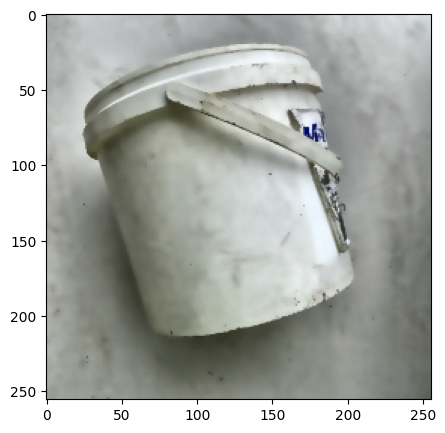

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Predicted class index: 6
Predicted category: Plastic
True Label index : 6


In [38]:
testing_image_path,testing_true_label= extract_image(6)
prediction_single_image(testing_image_path,testing_true_label)
